In [18]:
import torch
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms

In [19]:
batch_size = 32
train_dataset = dsets.MNIST(root='.',
                            train=True,
                            transform=transforms.ToTensor(),
                            download=True)

test_dataset = dsets.MNIST(root='.',
                           train=False, 
                           transform=transforms.ToTensor(),
                           download=True)


train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

In [20]:
print("* Размер train\n [количество_примеров, высота_картинки, ширина_картинки]: \n", train_dataset.train_data.shape)
print("\n* Размер test\n [количество_примеров, высота_картинки, ширина_картинки]: \n", test_dataset.test_data.shape)
print("\nМетки классов в датасете: ", train_dataset.train_labels.unique())

* Размер train
 [количество_примеров, высота_картинки, ширина_картинки]: 
 torch.Size([60000, 28, 28])

* Размер test
 [количество_примеров, высота_картинки, ширина_картинки]: 
 torch.Size([10000, 28, 28])

Метки классов в датасете:  tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:75: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:80: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:65: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


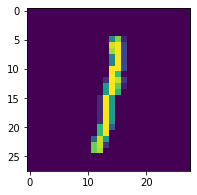

In [21]:
import numpy as np
from matplotlib import pyplot as plt

fig=plt.figure(figsize=(8, 3))

idx = np.random.choice(150)
img = train_dataset.train_data[idx]

plt.imshow(img)
plt.show()

In [22]:
class LogisticRegression(nn.Module):
    def __init__(self, input_size, num_classes):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        logits = self.linear(x)
        return logits

In [23]:
# Задаем гиперпараметры
input_size = 784 # 28*28 -- мы вытянули в линию все пиксели картинки
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

In [24]:
# Создаем модель
model = LogisticRegression(input_size=input_size, num_classes=num_classes)

In [25]:
from torchvision import  models
[m for m in dir(models) if not m.startswith('_')]

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights',
 'RegNet_X_1_6GF_Weights',
 'R

In [26]:
model_ft = models.resnet18()
model_ft.fc = nn.Linear(512, 10)
for params in model_ft.parameters():
    params.requires_grad = False
params_to_train = model_ft.fc.parameters()
model = model_ft

In [ ]:
# Вопрос: model_ft['fc'] = nn.Linear(512, 10) - не работает, что тогда делать с теми моделями, выходной слой которых выглядит например так "final classifier" или такого названия не может существовать?

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [30]:
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.view(-1, 28*28)
        print(i)
        outputs = model.forward(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print ('epoch:%d/%d, %d Loss: %.4f' % (epoch, num_epochs,i +1 , loss.item()))

0


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [32, 784]

In [ ]:
# Не могу понять, как решать эту проблемы. По идее на предоубченной модели у нас должен изменяться только последний слой. А как там тогда подогнать первый слой? Или надо сидеть и искать предоубченную модель, которая работает с нужным нам набром фичей? Еще как идея - первый диненый слой, который бы перегонял 28*28 в нужный модели вид.

## Визуализация весов

In [ ]:
W = model.parameters().__next__().detach().numpy()
W.shape

In [ ]:
fig=plt.figure(figsize=(8, 3))
columns = 5
rows = 2
for i in range(1, columns*rows +1):
    img = W[i-1].reshape((28, 28))
    fig.add_subplot(rows, columns, i)
    plt.imshow(img)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

y_pred = np.array([0 for _ in range(num_classes)])
y_true = np.array([])
for images, labels in test_loader:
    images = images.view(-1, 28*28)
    outputs = model(images)
    y_true = np.append(y_true, labels.numpy())
    s = nn.Softmax()
    y_cur = s(outputs).detach().numpy()
    y_pred = np.vstack((y_pred, y_cur))

y_pred = y_pred[1:]

roc_auc_score(y_true, y_pred, multi_class='ovr')